
# Wolf Sheep Simple 3 — Simulação estilo NetLogo com Python

Este notebook implementa uma simulação inspirada no modelo **Wolf Sheep Simple 3 / Wolf Sheep Predation** do NetLogo.

A proposta é reproduzir, em Python, uma dinâmica ecológica baseada em agentes, usando:

- 🐑 **Ovelhas**, que comem grama.
- 🐺 **Lobos**, que caçam ovelhas.
- 🌿 **Grama**, que cresce novamente ao longo do tempo.
- ⚡ **Energia**, que controla sobrevivência e reprodução.
- 📈 **Métricas ecológicas**, para analisar equilíbrio, colapso e ciclos populacionais.
- 🎞️ **Animação temporal**, para visualizar a evolução do sistema.
- 🧪 **Experimentos tipo BehaviorSpace**, para testar vários cenários automaticamente.

O notebook não depende de `nl4py` nem de NetLogo instalado. Toda a simulação é feita diretamente em Python.



## 1. Introdução a Sistemas Complexos

Um **sistema complexo** é formado por muitos elementos interagindo localmente. Mesmo quando as regras individuais são simples, o comportamento coletivo pode ser difícil de prever.

Neste modelo:

- Cada ovelha segue regras simples: mover, gastar energia, comer grama, reproduzir e morrer.
- Cada lobo segue regras simples: mover, gastar energia, caçar ovelhas, reproduzir e morrer.
- A grama cresce nos patches do ambiente.
- A dinâmica global emerge da interação entre agentes e ambiente.

Esse tipo de modelo é útil para estudar:

- Relações predador-presa.
- Consumo e regeneração de recursos.
- Ciclos populacionais.
- Colapso ecológico.
- Sensibilidade a parâmetros.
- Emergência e auto-organização.



## 2. Importação das bibliotecas

Usaremos apenas bibliotecas comuns do ecossistema Python científico.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from dataclasses import dataclass
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation

plt.rcParams["figure.figsize"] = (10, 6)



## 3. Parâmetros gerais do modelo

Os parâmetros abaixo funcionam como os controles do NetLogo:

- Tamanho do mundo.
- Quantidade inicial de ovelhas.
- Quantidade inicial de lobos.
- Energia inicial dos agentes.
- Custo de movimento.
- Energia obtida ao comer.
- Crescimento da grama.
- Probabilidade de reprodução.


In [2]:

# =========================
# PARÂMETROS DO AMBIENTE
# =========================

grid_size = 40
grass_max = 10.0
grass_regrowth_rate = 0.5

# =========================
# POPULAÇÕES INICIAIS
# =========================

initial_sheep = 120
initial_wolves = 40

# =========================
# ENERGIA
# =========================

initial_sheep_energy = 20
initial_wolf_energy = 30

sheep_movement_cost = 1
wolf_movement_cost = 1

energy_gain_from_grass = 4
energy_gain_from_sheep = 20

# =========================
# REPRODUÇÃO
# =========================

sheep_reproduction_prob = 0.04
wolf_reproduction_prob = 0.03

# =========================
# SIMULAÇÃO
# =========================

n_steps = 300
random_seed = 42

np.random.seed(random_seed)
random.seed(random_seed)



## 4. Classe dos agentes

Cada agente possui:

- `x`: posição horizontal.
- `y`: posição vertical.
- `energy`: energia atual.
- `kind`: tipo do agente, podendo ser `"sheep"` ou `"wolf"`.

A movimentação usa uma vizinhança de Moore simplificada, isto é, o agente pode se deslocar para qualquer direção ao redor da célula atual.
O mundo é toroidal: ao sair por uma borda, o agente reaparece do outro lado.


In [3]:

@dataclass
class Agent:
    x: int
    y: int
    energy: float
    kind: str

    def move(self, size):
        dx = random.choice([-1, 0, 1])
        dy = random.choice([-1, 0, 1])

        self.x = (self.x + dx) % size
        self.y = (self.y + dy) % size

    def position(self):
        return (self.x, self.y)



## 5. Função `setup`

A função `setup()` inicializa o mundo:

- Cria a grama com valores aleatórios.
- Cria as ovelhas em posições aleatórias.
- Cria os lobos em posições aleatórias.
- Define a energia inicial de cada agente.


In [4]:

def setup(params=None):
    if params is None:
        params = {}

    size = params.get("grid_size", grid_size)
    seed = params.get("random_seed", random_seed)

    np.random.seed(seed)
    random.seed(seed)

    grass = np.random.uniform(
        low=0,
        high=params.get("grass_max", grass_max),
        size=(size, size)
    )

    sheep = [
        Agent(
            x=random.randrange(size),
            y=random.randrange(size),
            energy=params.get("initial_sheep_energy", initial_sheep_energy),
            kind="sheep"
        )
        for _ in range(params.get("initial_sheep", initial_sheep))
    ]

    wolves = [
        Agent(
            x=random.randrange(size),
            y=random.randrange(size),
            energy=params.get("initial_wolf_energy", initial_wolf_energy),
            kind="wolf"
        )
        for _ in range(params.get("initial_wolves", initial_wolves))
    ]

    return grass, sheep, wolves



## 6. Visualização estilo NetLogo com emojis

A visualização abaixo usa:

- Fundo verde para representar a grama.
- 🐑 para representar ovelhas.
- 🐺 para representar lobos.

Caso o ambiente não renderize emojis corretamente, a função também permite usar marcadores clássicos.


In [5]:

def plot_world(
    grass,
    sheep,
    wolves,
    tick=0,
    title="Wolf Sheep Simple 3",
    grass_max_value=None,
    use_emoji=True,
    show_grid=False,
    figsize=(10, 10)
):
    if grass_max_value is None:
        grass_max_value = grass_max

    fig, ax = plt.subplots(figsize=figsize)

    grass_map = ax.imshow(
        grass.T,
        origin="lower",
        cmap="Greens",
        vmin=0,
        vmax=grass_max_value,
        alpha=0.92
    )

    if use_emoji:
        for s in sheep:
            ax.text(
                s.x,
                s.y,
                "🐑",
                fontsize=8,
                ha="center",
                va="center",
                zorder=3
            )

        for w in wolves:
            ax.text(
                w.x,
                w.y,
                "🐺",
                fontsize=10,
                ha="center",
                va="center",
                zorder=4
            )

        # Legenda simbólica
        ax.scatter([], [], label=f"🐑 Ovelhas ({len(sheep)})")
        ax.scatter([], [], label=f"🐺 Lobos ({len(wolves)})")

    else:
        if sheep:
            ax.scatter(
                [s.x for s in sheep],
                [s.y for s in sheep],
                s=55,
                c="white",
                edgecolors="black",
                linewidths=0.8,
                marker="o",
                label=f"Ovelhas ({len(sheep)})",
                zorder=3
            )

        if wolves:
            ax.scatter(
                [w.x for w in wolves],
                [w.y for w in wolves],
                s=120,
                c="red",
                edgecolors="black",
                linewidths=1.2,
                marker="*",
                label=f"Lobos ({len(wolves)})",
                zorder=4
            )

    ax.set_title(f"{title} — tick {tick}", fontsize=15, fontweight="bold")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    if show_grid:
        ax.set_xticks(np.arange(-0.5, grass.shape[0], 1), minor=True)
        ax.set_yticks(np.arange(-0.5, grass.shape[1], 1), minor=True)
        ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.2, alpha=0.25)

    ax.legend(loc="upper right", framealpha=0.95)
    cbar = plt.colorbar(grass_map, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Quantidade de grama")

    plt.tight_layout()
    plt.show()



## 7. Estado inicial do modelo


C:\Users\lacer\AppData\Local\Temp\ipykernel_10352\955128006.py:93: UserWarning: Glyph 128017 (\N{SHEEP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lacer\AppData\Local\Temp\ipykernel_10352\955128006.py:93: UserWarning: Glyph 128058 (\N{WOLF FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lacer\anaconda3\envs\Analise_texto_cobenge26\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128017 (\N{SHEEP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lacer\anaconda3\envs\Analise_texto_cobenge26\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128058 (\N{WOLF FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


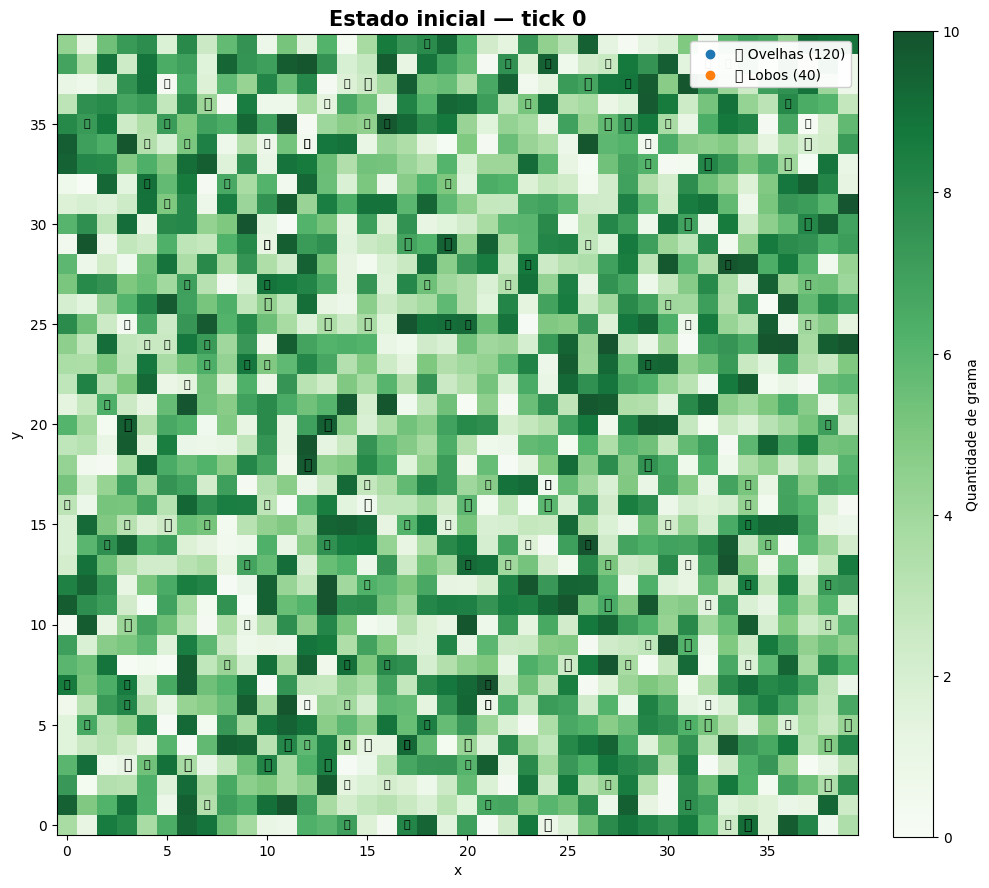

In [6]:

grass, sheep, wolves = setup()

plot_world(
    grass,
    sheep,
    wolves,
    tick=0,
    title="Estado inicial",
    grass_max_value=grass_max,
    use_emoji=True,
    show_grid=False
)



## 8. Regras das ovelhas

As ovelhas seguem a sequência:

1. Movem-se aleatoriamente.
2. Gastam energia.
3. Comem grama quando há grama suficiente.
4. Podem se reproduzir.
5. Morrem se a energia chegar a zero.


In [7]:

def update_sheep(sheep, grass, params=None):
    if params is None:
        params = {}

    size = params.get("grid_size", grid_size)
    move_cost = params.get("sheep_movement_cost", sheep_movement_cost)
    gain_grass = params.get("energy_gain_from_grass", energy_gain_from_grass)
    reproduction_prob = params.get("sheep_reproduction_prob", sheep_reproduction_prob)

    survivors = []
    newborns = []

    for s in sheep:
        s.move(size)
        s.energy -= move_cost

        x, y = s.position()

        if grass[x, y] >= gain_grass:
            s.energy += gain_grass
            grass[x, y] -= gain_grass

        if random.random() < reproduction_prob and s.energy > 2:
            child_energy = s.energy / 2
            s.energy = s.energy / 2
            newborns.append(Agent(s.x, s.y, child_energy, "sheep"))

        if s.energy > 0:
            survivors.append(s)

    survivors.extend(newborns)
    return survivors, grass



## 9. Regras dos lobos

Os lobos seguem a sequência:

1. Movem-se aleatoriamente.
2. Gastam energia.
3. Procuram ovelhas no mesmo patch.
4. Comem uma ovelha se houver alguma disponível.
5. Ganham energia ao comer.
6. Podem se reproduzir.
7. Morrem se a energia chegar a zero.


In [8]:

def update_wolves(wolves, sheep, params=None):
    if params is None:
        params = {}

    size = params.get("grid_size", grid_size)
    move_cost = params.get("wolf_movement_cost", wolf_movement_cost)
    gain_sheep = params.get("energy_gain_from_sheep", energy_gain_from_sheep)
    reproduction_prob = params.get("wolf_reproduction_prob", wolf_reproduction_prob)

    sheep_by_position = {}
    for idx, s in enumerate(sheep):
        sheep_by_position.setdefault(s.position(), []).append(idx)

    eaten_sheep = set()
    survivors = []
    newborns = []

    for w in wolves:
        w.move(size)
        w.energy -= move_cost

        pos = w.position()

        if pos in sheep_by_position:
            available = [
                idx for idx in sheep_by_position[pos]
                if idx not in eaten_sheep
            ]

            if available:
                chosen = available[0]
                eaten_sheep.add(chosen)
                w.energy += gain_sheep

        if random.random() < reproduction_prob and w.energy > 2:
            child_energy = w.energy / 2
            w.energy = w.energy / 2
            newborns.append(Agent(w.x, w.y, child_energy, "wolf"))

        if w.energy > 0:
            survivors.append(w)

    remaining_sheep = [
        s for idx, s in enumerate(sheep)
        if idx not in eaten_sheep
    ]

    survivors.extend(newborns)
    return survivors, remaining_sheep, len(eaten_sheep)



## 10. Crescimento da grama

A grama cresce a cada tick até o limite máximo.


In [9]:

def regrow_grass(grass, params=None):
    if params is None:
        params = {}

    rate = params.get("grass_regrowth_rate", grass_regrowth_rate)
    max_value = params.get("grass_max", grass_max)

    grass = grass + rate
    grass[grass > max_value] = max_value

    return grass



## 11. Métricas ecológicas

Além de contar o número de lobos e ovelhas, registraremos:

- Grama média.
- Energia média das ovelhas.
- Energia média dos lobos.
- Proporção de grama disponível.
- Biomassa aproximada.
- Número de ovelhas predadas por tick.
- Indicador de extinção.


In [10]:

def collect_metrics(tick, grass, sheep, wolves, eaten_sheep=0, params=None):
    if params is None:
        params = {}

    max_value = params.get("grass_max", grass_max)

    sheep_energy = [s.energy for s in sheep]
    wolf_energy = [w.energy for w in wolves]

    sheep_count = len(sheep)
    wolf_count = len(wolves)

    mean_grass = float(np.mean(grass))
    grass_available_ratio = float(np.mean(grass / max_value))

    mean_sheep_energy = float(np.mean(sheep_energy)) if sheep_energy else 0.0
    mean_wolf_energy = float(np.mean(wolf_energy)) if wolf_energy else 0.0

    total_sheep_energy = float(np.sum(sheep_energy)) if sheep_energy else 0.0
    total_wolf_energy = float(np.sum(wolf_energy)) if wolf_energy else 0.0
    total_grass_biomass = float(np.sum(grass))

    total_biomass_proxy = total_sheep_energy + total_wolf_energy + total_grass_biomass

    return {
        "tick": tick,
        "sheep": sheep_count,
        "wolves": wolf_count,
        "mean_grass": mean_grass,
        "grass_available_ratio": grass_available_ratio,
        "mean_sheep_energy": mean_sheep_energy,
        "mean_wolf_energy": mean_wolf_energy,
        "total_sheep_energy": total_sheep_energy,
        "total_wolf_energy": total_wolf_energy,
        "total_grass_biomass": total_grass_biomass,
        "total_biomass_proxy": total_biomass_proxy,
        "eaten_sheep": eaten_sheep,
        "sheep_extinct": sheep_count == 0,
        "wolves_extinct": wolf_count == 0
    }



## 12. Execução completa da simulação

A função `run_simulation()` executa o ciclo completo do modelo.

Ela retorna:

- `df_history`: tabela com as métricas por tick.
- `frames`: estados salvos para animação.
- `grass`, `sheep`, `wolves`: estado final.


In [11]:

def copy_agents(agents):
    return [Agent(a.x, a.y, a.energy, a.kind) for a in agents]


def run_simulation(params=None, save_frames=True, frame_interval=5):
    if params is None:
        params = {}

    steps = params.get("n_steps", n_steps)

    grass, sheep, wolves = setup(params)

    history = []
    frames = []

    for tick in range(steps + 1):
        history.append(
            collect_metrics(
                tick=tick,
                grass=grass,
                sheep=sheep,
                wolves=wolves,
                eaten_sheep=0,
                params=params
            )
        )

        if save_frames and tick % frame_interval == 0:
            frames.append({
                "tick": tick,
                "grass": grass.copy(),
                "sheep": copy_agents(sheep),
                "wolves": copy_agents(wolves)
            })

        if len(sheep) == 0 and len(wolves) == 0:
            break

        sheep, grass = update_sheep(sheep, grass, params)
        wolves, sheep, eaten = update_wolves(wolves, sheep, params)
        grass = regrow_grass(grass, params)

        if history:
            history[-1]["eaten_sheep"] = eaten

    df_history = pd.DataFrame(history)

    return df_history, frames, grass, sheep, wolves



## 13. Rodando a simulação principal


In [12]:

params_base = {
    "grid_size": grid_size,
    "grass_max": grass_max,
    "grass_regrowth_rate": grass_regrowth_rate,
    "initial_sheep": initial_sheep,
    "initial_wolves": initial_wolves,
    "initial_sheep_energy": initial_sheep_energy,
    "initial_wolf_energy": initial_wolf_energy,
    "sheep_movement_cost": sheep_movement_cost,
    "wolf_movement_cost": wolf_movement_cost,
    "energy_gain_from_grass": energy_gain_from_grass,
    "energy_gain_from_sheep": energy_gain_from_sheep,
    "sheep_reproduction_prob": sheep_reproduction_prob,
    "wolf_reproduction_prob": wolf_reproduction_prob,
    "n_steps": n_steps,
    "random_seed": random_seed
}

df_history, frames, final_grass, final_sheep, final_wolves = run_simulation(
    params=params_base,
    save_frames=True,
    frame_interval=5
)

df_history.head()


,tick,sheep,wolves,mean_grass,grass_available_ratio,mean_sheep_energy,mean_wolf_energy,total_sheep_energy,total_wolf_energy,total_grass_biomass,total_biomass_proxy,eaten_sheep,sheep_extinct,wolves_extinct
0,0,120,40,4.985377,0.498538,20.000000,30.000000,2400.0,1200.0,7976.602967,11576.602967,4,False,False
1,1,122,40,5.303812,0.530381,20.290984,31.000000,2475.5,1240.0,8486.099909,12201.599909,2,False,False
2,2,125,40,5.576932,0.557693,20.876000,31.000000,2609.5,1240.0,8923.091335,12772.591335,6,False,False
3,3,125,42,5.846139,0.584614,21.012000,31.428571,2626.5,1320.0,9353.822903,13300.322903,6,False,False
4,4,123,42,6.113036,0.611304,21.353659,33.285714,2626.5,1398.0,9780.858046,13805.358046,2,False,False



## 14. Estado final da simulação


C:\Users\lacer\AppData\Local\Temp\ipykernel_10352\955128006.py:93: UserWarning: Glyph 128017 (\N{SHEEP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lacer\AppData\Local\Temp\ipykernel_10352\955128006.py:93: UserWarning: Glyph 128058 (\N{WOLF FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lacer\anaconda3\envs\Analise_texto_cobenge26\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128017 (\N{SHEEP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lacer\anaconda3\envs\Analise_texto_cobenge26\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128058 (\N{WOLF FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


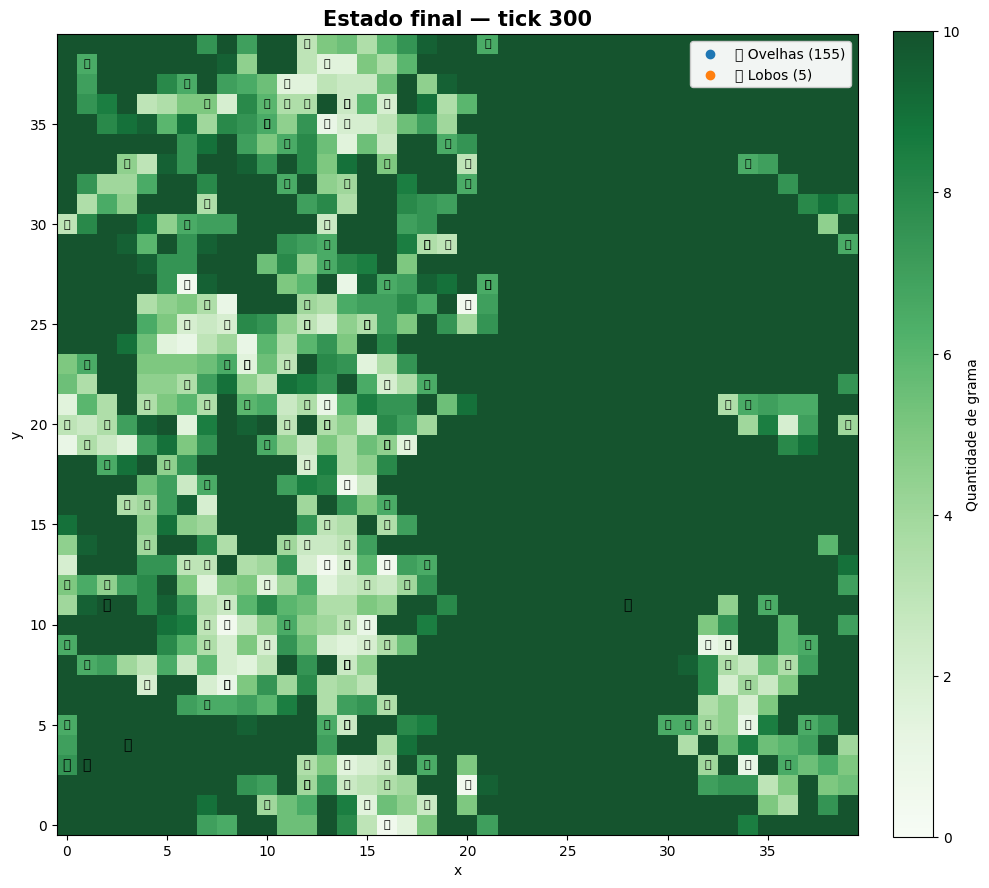

In [13]:

plot_world(
    final_grass,
    final_sheep,
    final_wolves,
    tick=int(df_history["tick"].iloc[-1]),
    title="Estado final",
    grass_max_value=grass_max,
    use_emoji=True
)



## 15. Gráfico de população: ovelhas × lobos

Este gráfico permite observar ciclos populacionais e possíveis colapsos.


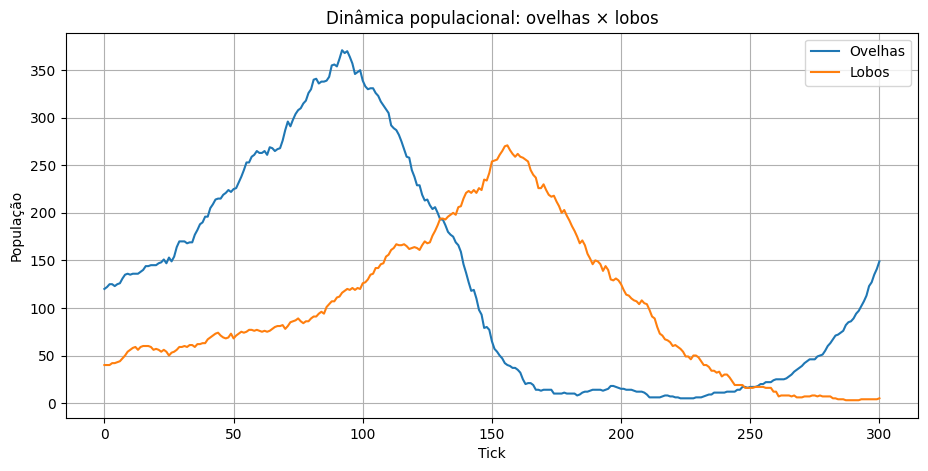

In [14]:

plt.figure(figsize=(11, 5))
plt.plot(df_history["tick"], df_history["sheep"], label="Ovelhas")
plt.plot(df_history["tick"], df_history["wolves"], label="Lobos")
plt.title("Dinâmica populacional: ovelhas × lobos")
plt.xlabel("Tick")
plt.ylabel("População")
plt.legend()
plt.grid(True)
plt.show()



## 16. Grama média e disponibilidade de recurso

A grama funciona como recurso primário do sistema.
Quando a grama diminui muito, as ovelhas perdem energia e a população de lobos pode ser afetada indiretamente.


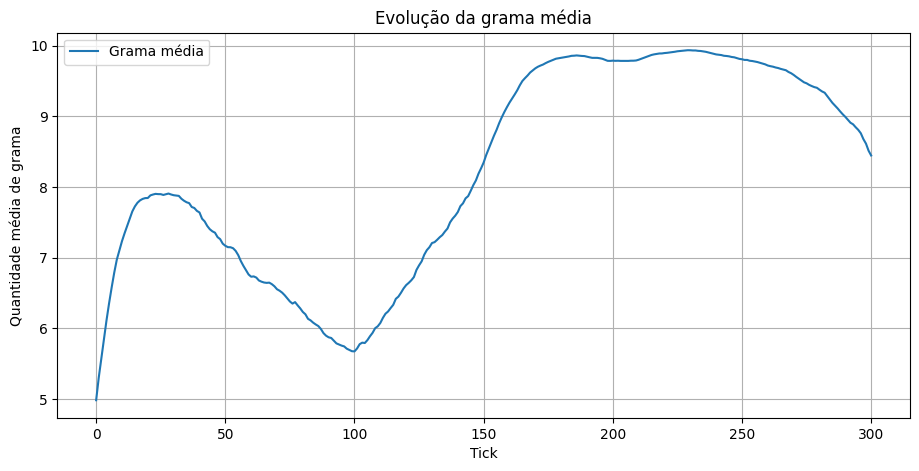

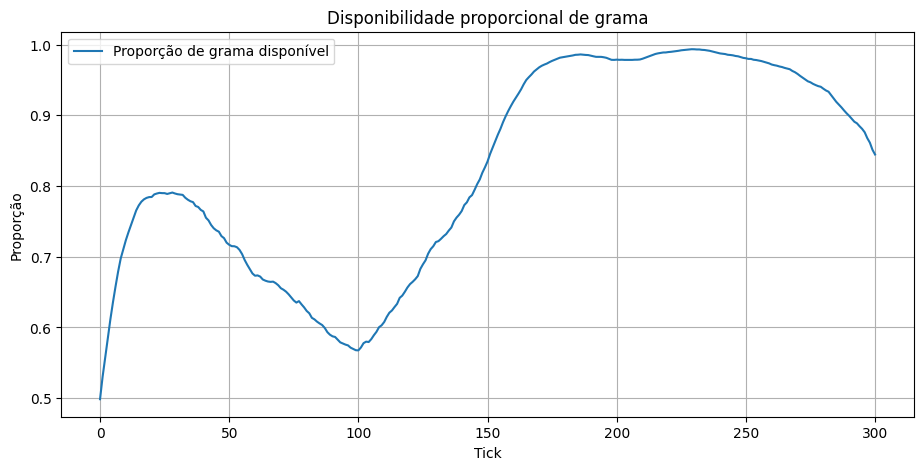

In [15]:

plt.figure(figsize=(11, 5))
plt.plot(df_history["tick"], df_history["mean_grass"], label="Grama média")
plt.title("Evolução da grama média")
plt.xlabel("Tick")
plt.ylabel("Quantidade média de grama")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(df_history["tick"], df_history["grass_available_ratio"], label="Proporção de grama disponível")
plt.title("Disponibilidade proporcional de grama")
plt.xlabel("Tick")
plt.ylabel("Proporção")
plt.legend()
plt.grid(True)
plt.show()



## 17. Energia média dos agentes

A energia representa a capacidade de sobrevivência e reprodução.


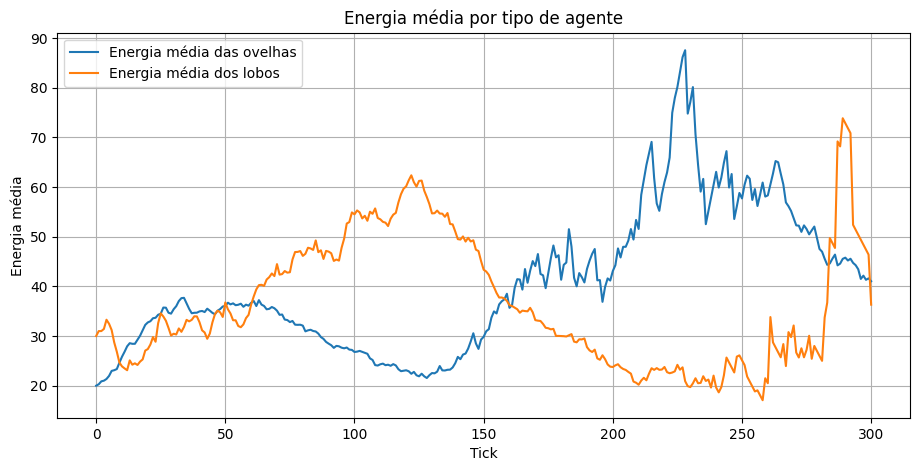

In [16]:

plt.figure(figsize=(11, 5))
plt.plot(df_history["tick"], df_history["mean_sheep_energy"], label="Energia média das ovelhas")
plt.plot(df_history["tick"], df_history["mean_wolf_energy"], label="Energia média dos lobos")
plt.title("Energia média por tipo de agente")
plt.xlabel("Tick")
plt.ylabel("Energia média")
plt.legend()
plt.grid(True)
plt.show()



## 18. Métrica de predação

A quantidade de ovelhas comidas por tick ajuda a entender a pressão predatória exercida pelos lobos.


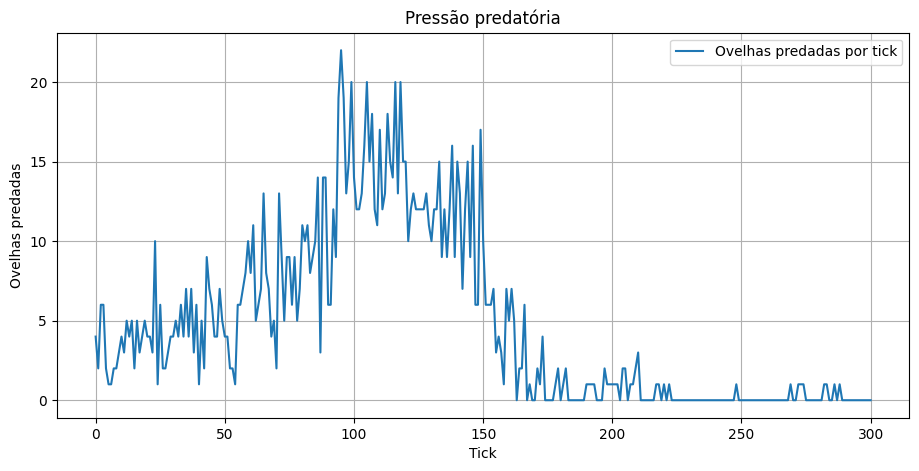

In [17]:

plt.figure(figsize=(11, 5))
plt.plot(df_history["tick"], df_history["eaten_sheep"], label="Ovelhas predadas por tick")
plt.title("Pressão predatória")
plt.xlabel("Tick")
plt.ylabel("Ovelhas predadas")
plt.legend()
plt.grid(True)
plt.show()



## 19. Biomassa aproximada do sistema

A biomassa aproximada soma:

- Energia total das ovelhas.
- Energia total dos lobos.
- Quantidade total de grama.

Não é uma biomassa ecológica exata, mas funciona como um indicador agregado do sistema.


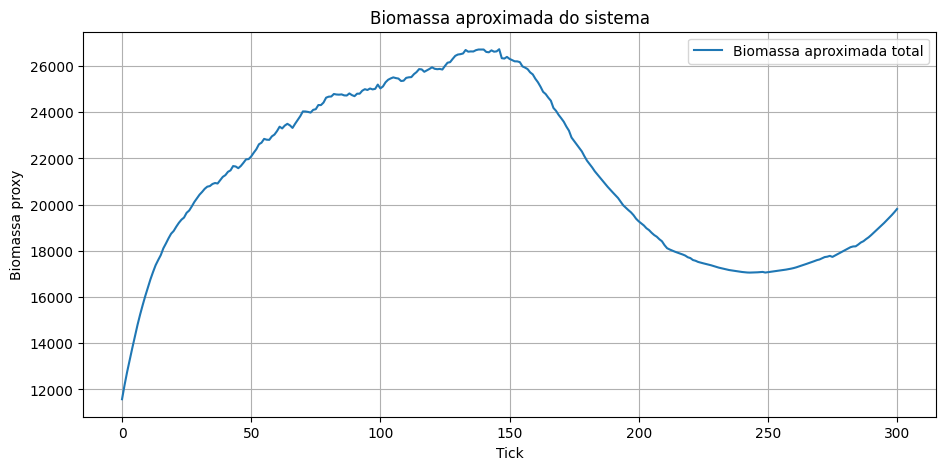

In [18]:

plt.figure(figsize=(11, 5))
plt.plot(df_history["tick"], df_history["total_biomass_proxy"], label="Biomassa aproximada total")
plt.title("Biomassa aproximada do sistema")
plt.xlabel("Tick")
plt.ylabel("Biomassa proxy")
plt.legend()
plt.grid(True)
plt.show()



## 20. Animação temporal

A célula abaixo cria uma animação do modelo.

Observação: se houver muitos agentes, a animação com emojis pode ficar mais pesada. Para maior desempenho, altere `use_emoji_animation = False`.


In [19]:

def animate_simulation(frames, grass_max_value=grass_max, use_emoji_animation=True):
    fig, ax = plt.subplots(figsize=(8, 8))

    def update(frame):
        ax.clear()

        grass = frame["grass"]
        sheep = frame["sheep"]
        wolves = frame["wolves"]
        tick = frame["tick"]

        ax.imshow(
            grass.T,
            origin="lower",
            cmap="Greens",
            vmin=0,
            vmax=grass_max_value,
            alpha=0.92
        )

        if use_emoji_animation:
            for s in sheep:
                ax.text(s.x, s.y, "🐑", fontsize=7, ha="center", va="center", zorder=3)
            for w in wolves:
                ax.text(w.x, w.y, "🐺", fontsize=9, ha="center", va="center", zorder=4)
        else:
            if sheep:
                ax.scatter(
                    [s.x for s in sheep],
                    [s.y for s in sheep],
                    s=30,
                    c="white",
                    edgecolors="black",
                    linewidths=0.5,
                    marker="o",
                    label=f"Ovelhas ({len(sheep)})",
                    zorder=3
                )
            if wolves:
                ax.scatter(
                    [w.x for w in wolves],
                    [w.y for w in wolves],
                    s=70,
                    c="red",
                    edgecolors="black",
                    linewidths=0.7,
                    marker="*",
                    label=f"Lobos ({len(wolves)})",
                    zorder=4
                )

        ax.set_title(f"Wolf Sheep Simple 3 — tick {tick}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_xlim(-0.5, grass.shape[0] - 0.5)
        ax.set_ylim(-0.5, grass.shape[1] - 0.5)

    anim = FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=250,
        repeat=False
    )

    plt.close(fig)
    return anim


anim = animate_simulation(frames, grass_max_value=grass_max, use_emoji_animation=True)
HTML(anim.to_jshtml())


C:\Users\lacer\AppData\Local\Temp\ipykernel_10352\1210676854.py:71: UserWarning: Glyph 128017 (\N{SHEEP}) missing from font(s) DejaVu Sans.
  HTML(anim.to_jshtml())
C:\Users\lacer\AppData\Local\Temp\ipykernel_10352\1210676854.py:71: UserWarning: Glyph 128058 (\N{WOLF FACE}) missing from font(s) DejaVu Sans.
  HTML(anim.to_jshtml())



## 21. Exportação dos resultados para CSV

A tabela de histórico pode ser exportada para CSV e usada em análises externas.


In [ ]:

csv_path = "wolf_sheep_simple_3_resultados.csv"
df_history.to_csv(csv_path, index=False, encoding="utf-8-sig")
csv_path



## 22. Resumo estatístico da simulação


In [ ]:

summary = {
    "ticks_simulados": int(df_history["tick"].max()),
    "ovelhas_iniciais": int(df_history["sheep"].iloc[0]),
    "lobos_iniciais": int(df_history["wolves"].iloc[0]),
    "ovelhas_finais": int(df_history["sheep"].iloc[-1]),
    "lobos_finais": int(df_history["wolves"].iloc[-1]),
    "max_ovelhas": int(df_history["sheep"].max()),
    "max_lobos": int(df_history["wolves"].max()),
    "media_grama_final": float(df_history["mean_grass"].iloc[-1]),
    "total_ovelhas_predadas": int(df_history["eaten_sheep"].sum()),
    "ovelhas_extintas": bool(df_history["sheep"].iloc[-1] == 0),
    "lobos_extintos": bool(df_history["wolves"].iloc[-1] == 0)
}

pd.DataFrame([summary])



## 23. Experimentos tipo NetLogo BehaviorSpace

O **BehaviorSpace**, no NetLogo, permite rodar o mesmo modelo várias vezes alterando parâmetros.

Abaixo fazemos uma versão em Python:

- Variamos a taxa de crescimento da grama.
- Variamos a quantidade inicial de lobos.
- Variamos a probabilidade de reprodução das ovelhas.
- Rodamos mais de uma repetição por cenário.
- Salvamos os resultados agregados.


In [ ]:

def run_behaviorspace_experiments():
    experiment_results = []

    grass_rates = [0.2, 0.5, 1.0]
    initial_wolves_values = [20, 40, 80]
    sheep_reproduction_values = [0.02, 0.04, 0.08]
    repetitions = 3

    experiment_id = 0

    for gr in grass_rates:
        for iw in initial_wolves_values:
            for sr in sheep_reproduction_values:
                for rep in range(repetitions):
                    experiment_id += 1

                    params = params_base.copy()
                    params.update({
                        "grass_regrowth_rate": gr,
                        "initial_wolves": iw,
                        "sheep_reproduction_prob": sr,
                        "n_steps": 200,
                        "random_seed": 1000 + experiment_id
                    })

                    df_exp, _, _, _, _ = run_simulation(
                        params=params,
                        save_frames=False
                    )

                    result = {
                        "experiment_id": experiment_id,
                        "repetition": rep + 1,
                        "grass_regrowth_rate": gr,
                        "initial_wolves": iw,
                        "sheep_reproduction_prob": sr,
                        "ticks_simulados": int(df_exp["tick"].max()),
                        "final_sheep": int(df_exp["sheep"].iloc[-1]),
                        "final_wolves": int(df_exp["wolves"].iloc[-1]),
                        "max_sheep": int(df_exp["sheep"].max()),
                        "max_wolves": int(df_exp["wolves"].max()),
                        "mean_sheep": float(df_exp["sheep"].mean()),
                        "mean_wolves": float(df_exp["wolves"].mean()),
                        "mean_grass": float(df_exp["mean_grass"].mean()),
                        "total_eaten_sheep": int(df_exp["eaten_sheep"].sum()),
                        "sheep_extinct_final": bool(df_exp["sheep"].iloc[-1] == 0),
                        "wolves_extinct_final": bool(df_exp["wolves"].iloc[-1] == 0)
                    }

                    experiment_results.append(result)

    return pd.DataFrame(experiment_results)


df_behaviorspace = run_behaviorspace_experiments()
df_behaviorspace.head()



## 24. Análise dos experimentos BehaviorSpace


In [ ]:

df_grouped = (
    df_behaviorspace
    .groupby(["grass_regrowth_rate", "initial_wolves", "sheep_reproduction_prob"])
    .agg(
        media_ovelhas_finais=("final_sheep", "mean"),
        media_lobos_finais=("final_wolves", "mean"),
        media_ovelhas=("mean_sheep", "mean"),
        media_lobos=("mean_wolves", "mean"),
        media_grama=("mean_grass", "mean"),
        taxa_extincao_ovelhas=("sheep_extinct_final", "mean"),
        taxa_extincao_lobos=("wolves_extinct_final", "mean")
    )
    .reset_index()
)

df_grouped.head()


In [ ]:

plt.figure(figsize=(11, 5))
for gr in sorted(df_behaviorspace["grass_regrowth_rate"].unique()):
    subset = df_behaviorspace[df_behaviorspace["grass_regrowth_rate"] == gr]
    grouped = subset.groupby("initial_wolves")["final_sheep"].mean()
    plt.plot(grouped.index, grouped.values, marker="o", label=f"grass_regrowth={gr}")

plt.title("BehaviorSpace: efeito dos lobos iniciais nas ovelhas finais")
plt.xlabel("Lobos iniciais")
plt.ylabel("Média de ovelhas finais")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

plt.figure(figsize=(11, 5))
for sr in sorted(df_behaviorspace["sheep_reproduction_prob"].unique()):
    subset = df_behaviorspace[df_behaviorspace["sheep_reproduction_prob"] == sr]
    grouped = subset.groupby("grass_regrowth_rate")["final_wolves"].mean()
    plt.plot(grouped.index, grouped.values, marker="o", label=f"sheep_reproduction={sr}")

plt.title("BehaviorSpace: efeito da grama e reprodução das ovelhas nos lobos finais")
plt.xlabel("Taxa de crescimento da grama")
plt.ylabel("Média de lobos finais")
plt.legend()
plt.grid(True)
plt.show()



## 25. Exportando os experimentos BehaviorSpace


In [ ]:

behaviorspace_csv_path = "wolf_sheep_behaviorspace_resultados.csv"
df_behaviorspace.to_csv(behaviorspace_csv_path, index=False, encoding="utf-8-sig")

grouped_csv_path = "wolf_sheep_behaviorspace_agregado.csv"
df_grouped.to_csv(grouped_csv_path, index=False, encoding="utf-8-sig")

behaviorspace_csv_path, grouped_csv_path



## 26. Interpretação final

Este modelo mostra que regras locais simples podem gerar padrões complexos.

Algumas leituras possíveis:

- Se a grama cresce lentamente, as ovelhas podem entrar em colapso por falta de alimento.
- Se há muitos lobos, as ovelhas podem ser eliminadas rapidamente.
- Se há poucas ovelhas, os lobos podem morrer por falta de alimento.
- Se a reprodução das ovelhas é alta e a grama cresce rápido, pode ocorrer explosão populacional.
- Ciclos populacionais podem aparecer quando há equilíbrio entre recurso, presa e predador.

Em termos de Sistemas Complexos, o modelo ilustra:

- Emergência.
- Não linearidade.
- Dependência de parâmetros.
- Feedback positivo e negativo.
- Colapso sistêmico.
- Dinâmica predador-presa.



## 27. Próximas extensões possíveis

Você pode ampliar este modelo adicionando:

1. Idade dos agentes.
2. Fome máxima.
3. Visão dos lobos.
4. Estratégia de fuga das ovelhas.
5. Reprodução dependente de energia.
6. Obstáculos no ambiente.
7. Estações do ano.
8. Doenças.
9. Migração.
10. Comparação com Lotka-Volterra.
11. Exportação de imagens por tick.
12. Dashboard com Streamlit.
